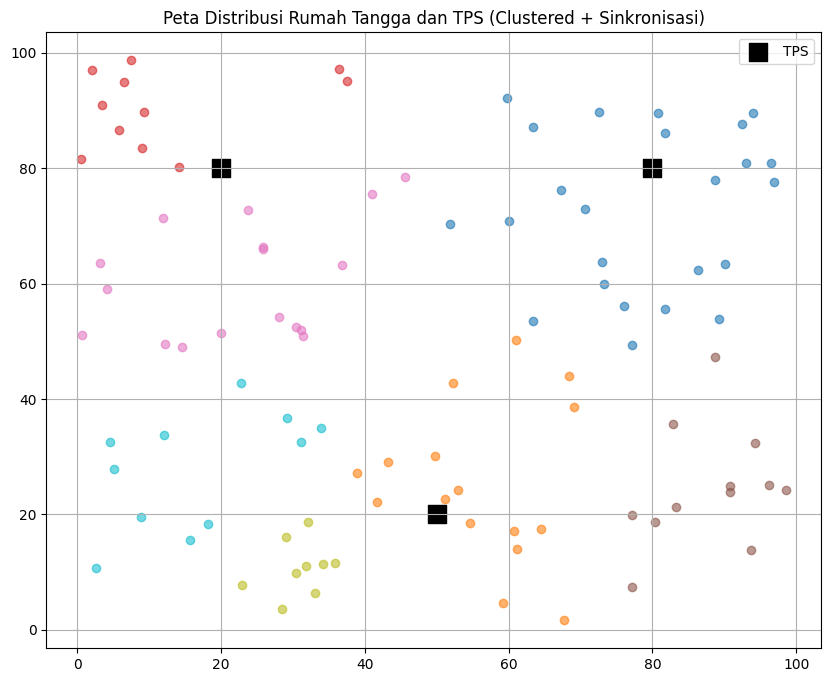

=== STATISTIK PENGELOLAAN ===
Total Jarak Semua Gerobak : 183.97 satuan
Total Jarak Semua Truk    : 1.00 satuan
Total Jarak Keseluruhan   : 184.97 satuan
Total Waktu Semua Gerobak : 1671.94 menit
Total Waktu Semua Truk    : 24.60 menit
Sisa Sampah di Rumah      : 42.37 kg
Sampah Tersimpan di Gerobak: 80.02 kg
Sampah Tersimpan di Truk   : 240.00 kg

=== SAMPLE REPORT PERGERAKAN ===
[6.16 Jam] G1: Ambil di Rumah 1 (0.59 kg)
[6.35 Jam] G1: Ambil di Rumah 4 (4.25 kg)
[6.62 Jam] G1: Ambil di Rumah 17 (5.23 kg)
[6.73 Jam] G1: Ambil di Rumah 25 (1.71 kg)
[6.89 Jam] G1: Ambil di Rumah 26 (3.22 kg)
[7.44 Jam] G1: Titip ke T2 (15.00 kg)
[6.19 Jam] G2: Ambil di Rumah 9 (1.13 kg)
[6.38 Jam] G2: Ambil di Rumah 10 (3.84 kg)
[6.60 Jam] G2: Ambil di Rumah 14 (4.99 kg)
[6.70 Jam] G2: Ambil di Rumah 15 (1.66 kg)
[6.89 Jam] G2: Ambil di Rumah 19 (3.38 kg)
[7.48 Jam] G2: Titip ke T2 (15.00 kg)
[8.41 Jam] T1: Ambil di TPS 0 (120.00 kg)
[7.44 Jam] T2: Terima dari G1 (15.00 kg)
[8.76 Jam] T2: Terima dari G1 

In [29]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

@dataclass
class House:
    id: int
    x: float
    y: float
    waste_kg: float
    collected: float = 0.0
    zone: int = -1

    @property
    def remaining_waste(self):
        return max(0.0, self.waste_kg - self.collected)

@dataclass
class TPS:
    id: int
    x: float
    y: float
    capacity_kg: float
    current_load: float = 0.0

    @property
    def available_capacity(self):
        return self.capacity_kg - self.current_load

@dataclass
class LogEntry:
    time_min: float
    vehicle_id: str
    action: str
    load_kg: float

@dataclass
class Vehicle:
    id: str
    vtype: str
    capacity_kg: float
    start_min: float
    end_min: float
    current_load: float = 0.0
    current_time: float = 0.0
    total_distance: float = 0.0
    position: Tuple[float, float] = (0.0, 0.0)
    log: List[LogEntry] = field(default_factory=list)
    zone: int = -1

    def __post_init__(self):
        self.current_time = self.start_min

    @property
    def available_capacity(self):
        return self.capacity_kg - self.current_load

    @property
    def is_operating(self):
        return self.current_time <= self.end_min

class Environment:
    def __init__(self):
        self.houses = []
        self.tps_list = []
        self.carts = []
        self.trucks = []
        self._generate()

    def _generate(self):
        coords = np.random.uniform(0, 100, (100, 2))
        for i in range(100):
            waste = round(np.random.uniform(0, 7), 2)
            self.houses.append(House(id=i, x=coords[i][0], y=coords[i][1], waste_kg=waste))
        
        tps_coords = [(20, 80), (80, 80), (50, 20)]
        for i, (tx, ty) in enumerate(tps_coords):
            cap = round(np.random.uniform(400, 500), 1)
            self.tps_list.append(TPS(id=i, x=tx, y=ty, capacity_kg=cap))
        
        self.n_carts = random.randint(5, 7)
        kmeans = KMeans(n_clusters=self.n_carts, random_state=SEED).fit(coords)
        for i, label in enumerate(kmeans.labels_):
            self.houses[i].zone = label

        for i in range(self.n_carts):
            tps = self.tps_list[i % 3]
            self.carts.append(Vehicle(id=f'G{i+1}', vtype='cart', capacity_kg=15.0, 
                                      start_min=6*60, end_min=15*60, 
                                      position=(tps.x, tps.y), zone=i))
            
        n_trucks = random.randint(2, 4)
        for i in range(n_trucks):
            tps = self.tps_list[i % 3]
            self.trucks.append(Vehicle(id=f'T{i+1}', vtype='truck', capacity_kg=200.0, 
                                       start_min=8*60, end_min=17*60, 
                                       position=(tps.x, tps.y)))

    def dist(self, p1, p2):
        raw = np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
        return max(1.0, min(5.0, raw / 20.0))

def run_simulation(env):
    for cart in env.carts:
        zone_houses = [h for h in env.houses if h.zone == cart.zone]
        for house in zone_houses:
            if house.remaining_waste > 0 and cart.is_operating:
                if cart.available_capacity <= 0:
                    tps = env.tps_list[0]
                    best_dest = "tps"
                    min_dist = env.dist(cart.position, (tps.x, tps.y))
                    target_truck = None
                    
                    for truck in env.trucks:
                        if truck.is_operating and truck.available_capacity >= cart.current_load:
                            d_truck = env.dist(cart.position, truck.position)
                            if d_truck < min_dist:
                                min_dist = d_truck
                                best_dest = "truck"
                                target_truck = truck
                    
                    time_to_dest = min_dist * 3
                    if cart.current_time + time_to_dest <= cart.end_min:
                        cart.current_time += time_to_dest
                        cart.total_distance += min_dist
                        
                        if best_dest == "truck" and target_truck is not None:
                            cart.position = target_truck.position
                            unload_time = cart.current_load * 2
                            if cart.current_time + unload_time <= cart.end_min:
                                cart.current_time += unload_time
                                target_truck.current_load += cart.current_load
                                cart.log.append(LogEntry(cart.current_time, cart.id, f'Titip ke {target_truck.id}', cart.current_load))
                                target_truck.log.append(LogEntry(cart.current_time, target_truck.id, f'Terima dari {cart.id}', cart.current_load))
                                cart.current_load = 0.0
                        else:
                            cart.position = (tps.x, tps.y)
                            unload_time = cart.current_load * 2
                            if cart.current_time + unload_time <= cart.end_min:
                                cart.current_time += unload_time
                                tps.current_load += cart.current_load
                                cart.log.append(LogEntry(cart.current_time, cart.id, f'Buang ke TPS {tps.id}', cart.current_load))
                                cart.current_load = 0.0

                d = env.dist(cart.position, (house.x, house.y))
                travel_time = d * 3
                if cart.current_time + travel_time <= cart.end_min:
                    cart.current_time += travel_time
                    cart.total_distance += d
                    cart.position = (house.x, house.y)
                    
                    take = min(cart.available_capacity, house.remaining_waste)
                    load_time = take * 2
                    if cart.current_time + load_time <= cart.end_min:
                        cart.current_time += load_time
                        cart.current_load += take
                        house.collected += take
                        cart.log.append(LogEntry(cart.current_time, cart.id, f'Ambil di Rumah {house.id}', take))

    for truck in env.trucks:
        for tps in env.tps_list:
            if tps.current_load > 0 and truck.is_operating and truck.available_capacity > 0:
                d = env.dist(truck.position, (tps.x, tps.y))
                travel_time = (d / 5.0) * 3
                if truck.current_time + travel_time <= truck.end_min:
                    truck.current_time += travel_time
                    truck.total_distance += d
                    truck.position = (tps.x, tps.y)
                    
                    take = min(truck.available_capacity, tps.current_load)
                    load_time = (take / 10.0) * 2
                    if truck.current_time + load_time <= truck.end_min:
                        truck.current_time += load_time
                        truck.current_load += take
                        tps.current_load -= take
                        truck.log.append(LogEntry(truck.current_time, truck.id, f'Ambil di TPS {tps.id}', take))

env = Environment()
run_simulation(env)

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', env.n_carts)
for i, h in enumerate(env.houses):
    plt.scatter(h.x, h.y, color=colors(h.zone), marker='o', alpha=0.6)

tx = [t.x for t in env.tps_list]
ty = [t.y for t in env.tps_list]
plt.scatter(tx, ty, c='black', marker='s', s=150, label='TPS')

plt.title('Peta Distribusi Rumah Tangga dan TPS (Clustered + Sinkronisasi)')
plt.legend()
plt.grid(True)
plt.show()

total_dist_carts = sum(c.total_distance for c in env.carts)
total_dist_trucks = sum(t.total_distance for t in env.trucks)
total_time_carts = sum(c.current_time - c.start_min for c in env.carts)
total_time_trucks = sum(t.current_time - t.start_min for t in env.trucks)
rem_house = sum(h.remaining_waste for h in env.houses)
rem_carts = sum(c.current_load for c in env.carts)
rem_trucks = sum(t.current_load for t in env.trucks)

print("=== STATISTIK PENGELOLAAN ===")
print(f"Total Jarak Semua Gerobak : {total_dist_carts:.2f} satuan")
print(f"Total Jarak Semua Truk    : {total_dist_trucks:.2f} satuan")
print(f"Total Jarak Keseluruhan   : {total_dist_carts + total_dist_trucks:.2f} satuan")
print(f"Total Waktu Semua Gerobak : {total_time_carts:.2f} menit")
print(f"Total Waktu Semua Truk    : {total_time_trucks:.2f} menit")
print(f"Sisa Sampah di Rumah      : {rem_house:.2f} kg")
print(f"Sampah Tersimpan di Gerobak: {rem_carts:.2f} kg")
print(f"Sampah Tersimpan di Truk   : {rem_trucks:.2f} kg")

print("\n=== SAMPLE REPORT PERGERAKAN ===")
for c in env.carts[:2]:
    for entry in c.log[:6]:
        print(f"[{entry.time_min/60:.2f} Jam] {entry.vehicle_id}: {entry.action} ({entry.load_kg:.2f} kg)")
for t in env.trucks[:2]:
    for entry in t.log[:6]:
        print(f"[{entry.time_min/60:.2f} Jam] {entry.vehicle_id}: {entry.action} ({entry.load_kg:.2f} kg)")